In [1]:
!pip install tensorflow opencv-python matplotlib seaborn pandas scikit-learn

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
import os
import cv2
import numpy as np

# Define the dataset path
dataset_path = "/content/dataset/PlantVillage"

# Set the image size (e.g., 128x128 pixels)
IMG_SIZE = 128

images = []
labels = []

print("Starting image loading and preprocessing...")

# Loop through each disease folder in the dataset path
for disease in os.listdir(dataset_path):
    disease_folder = os.path.join(dataset_path, disease)

    # Ensure it's a directory
    if os.path.isdir(disease_folder):
        count = 0
        # Loop through each image in the disease folder
        for img_name in os.listdir(disease_folder):
            img_path = os.path.join(disease_folder, img_name)

            # Read the image using OpenCV
            img = cv2.imread(img_path)

            if img is not None:
                # Resize the image to the specified IMG_SIZE
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                # Normalize pixel values to the range [0, 1]
                img = img.astype("float32") / 255.0

                images.append(img)
                labels.append(disease)
                count += 1
        print(f"Loaded {count} images from class: {disease}")

# Convert the list of images to a NumPy array
images = np.array(images)

print("\nImage loading and preprocessing complete!")
print("Total Images loaded:", len(images))
print("Total unique classes:", len(set(labels)))

Starting image loading and preprocessing...
Loaded 1000 images from class: Potato___Late_blight
Loaded 1909 images from class: Tomato_Late_blight
Loaded 373 images from class: Tomato__Tomato_mosaic_virus
Loaded 1000 images from class: Tomato_Early_blight
Loaded 152 images from class: Potato___healthy
Loaded 2127 images from class: Tomato_Bacterial_spot
Loaded 997 images from class: Pepper__bell___Bacterial_spot
Loaded 1478 images from class: Pepper__bell___healthy
Loaded 1591 images from class: Tomato_healthy
Loaded 3208 images from class: Tomato__Tomato_YellowLeaf__Curl_Virus
Loaded 1676 images from class: Tomato_Spider_mites_Two_spotted_spider_mite
Loaded 1404 images from class: Tomato__Target_Spot
Loaded 1000 images from class: Potato___Early_blight
Loaded 1771 images from class: Tomato_Septoria_leaf_spot
Loaded 952 images from class: Tomato_Leaf_Mold

Image loading and preprocessing complete!
Total Images loaded: 20638
Total unique classes: 15


In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [4]:
import zipfile

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [6]:
dataset_path = "/content/dataset/PlantVillage"

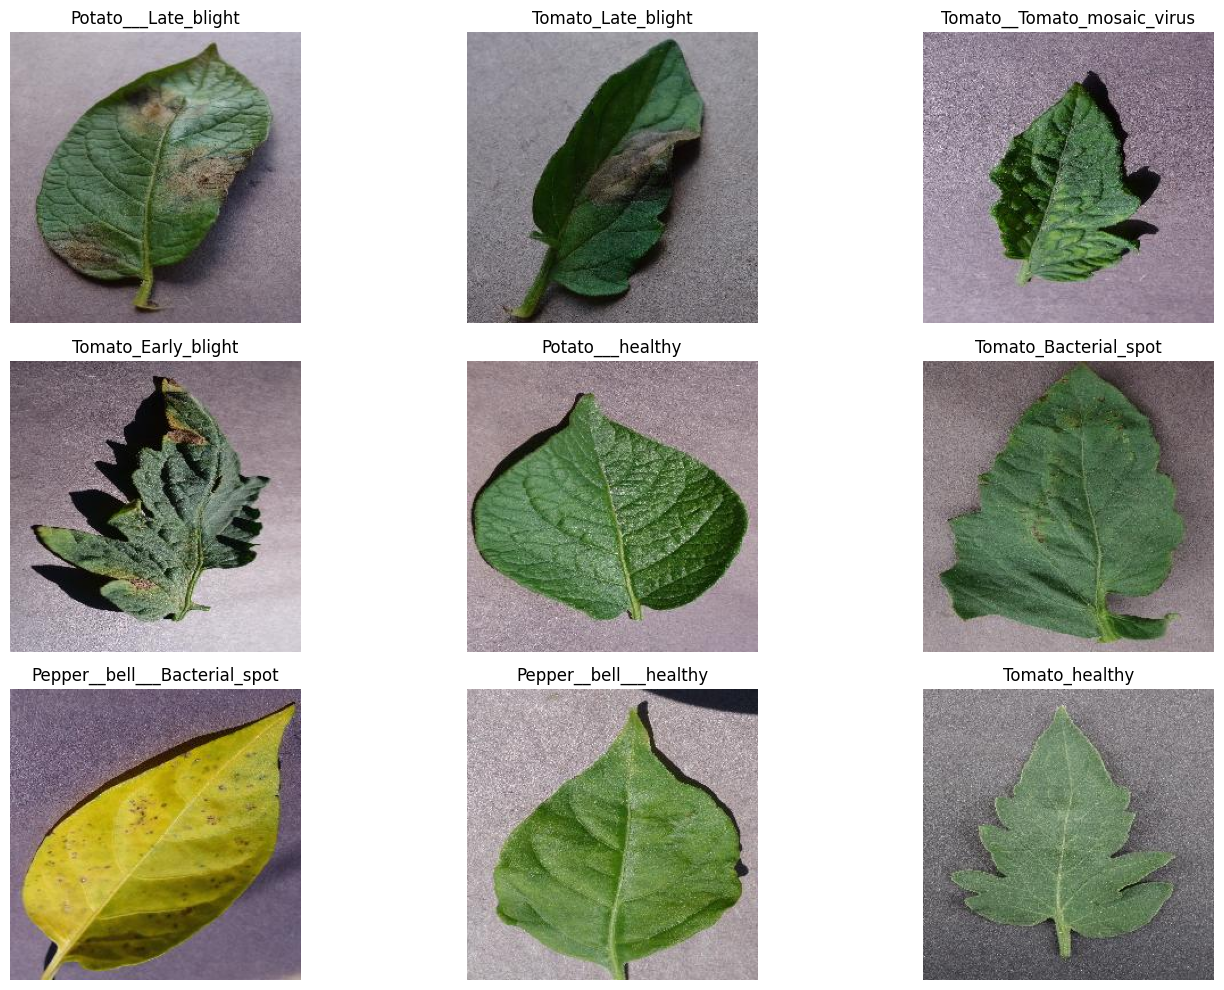

In [8]:
import os
import random
import matplotlib.pyplot as plt

classes = os.listdir(dataset_path)

plt.figure(figsize=(15,10))

for i, disease in enumerate(classes[:9]):

    folder = os.path.join(dataset_path, disease)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = plt.imread(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import cv2
import numpy as np

heights = []
widths = []

for disease in classes:

    folder = os.path.join(dataset_path, disease)

    for img_name in os.listdir(folder)[:20]:

        img = cv2.imread(
            os.path.join(folder, img_name)
        )

        if img is not None:

            heights.append(img.shape[0])
            widths.append(img.shape[1])

print("Average Height:", np.mean(heights))
print("Average Width:", np.mean(widths))

Average Height: 256.0
Average Width: 256.0


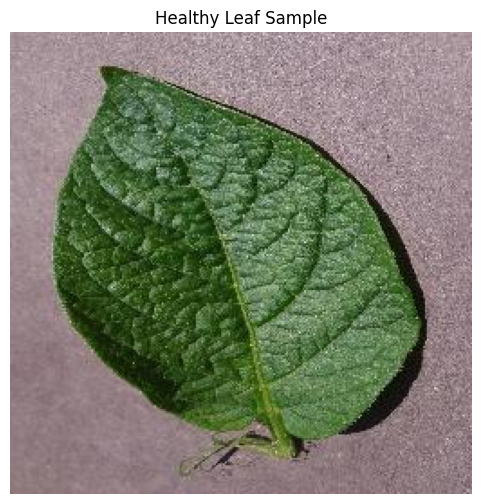

In [19]:
healthy_class = [c for c in classes if "healthy" in c.lower()][0]

healthy_img = random.choice(
    os.listdir(
        os.path.join(dataset_path, healthy_class)
    )
)

healthy_path = os.path.join(
    dataset_path,
    healthy_class,
    healthy_img
)

healthy = plt.imread(healthy_path)

plt.figure(figsize=(6,6))
plt.imshow(healthy)
plt.title("Healthy Leaf Sample")
plt.axis("off")
plt.show()

In [20]:
dataset_path = "/content/dataset/PlantVillage"

In [21]:
# ==========================================
# WEEK 1 - IMAGE PREPROCESSING
# ==========================================

import os
import cv2
import numpy as np

# Use 128 instead of 224 to reduce RAM usage
IMG_SIZE = 128

images = []
labels = []

print("Starting image loading process...")

for disease in os.listdir(dataset_path):

    disease_folder = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_folder):

        count = 0

        for img_name in os.listdir(disease_folder):

            img_path = os.path.join(disease_folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize image
                img = img.astype("float32") / 255.0

                images.append(img)
                labels.append(disease)

                count += 1

        print(f"Loaded {count} images from class: {disease}")

print("\nConverting images to NumPy array...")

images = np.array(images, dtype="float32")

print("\nDataset Loaded Successfully!")
print("Total Images:", len(images))
print("Total Labels:", len(labels))
print("Total Classes:", len(set(labels)))

print("\nClass Names:")
print(sorted(list(set(labels))))

Starting image loading process...
Loaded 1000 images from class: Potato___Late_blight
Loaded 1909 images from class: Tomato_Late_blight
Loaded 373 images from class: Tomato__Tomato_mosaic_virus
Loaded 1000 images from class: Tomato_Early_blight
Loaded 152 images from class: Potato___healthy
Loaded 2127 images from class: Tomato_Bacterial_spot
Loaded 997 images from class: Pepper__bell___Bacterial_spot
Loaded 1478 images from class: Pepper__bell___healthy
Loaded 1591 images from class: Tomato_healthy
Loaded 3208 images from class: Tomato__Tomato_YellowLeaf__Curl_Virus
Loaded 1676 images from class: Tomato_Spider_mites_Two_spotted_spider_mite
Loaded 1404 images from class: Tomato__Target_Spot
Loaded 1000 images from class: Potato___Early_blight
Loaded 1771 images from class: Tomato_Septoria_leaf_spot
Loaded 952 images from class: Tomato_Leaf_Mold

Converting images to NumPy array...

Dataset Loaded Successfully!
Total Images: 20638
Total Labels: 20638
Total Classes: 15

Class Names:
['Pe

In [12]:
# Re-running image loading and preprocessing to define 'images' and 'labels'

import os
import cv2
import numpy as np

IMG_SIZE = 128

dataset_path = "/content/dataset/PlantVillage"

images = []
labels = []

print("Starting image loading process...")

for disease in os.listdir(dataset_path):

    disease_folder = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_folder):

        count = 0

        for img_name in os.listdir(disease_folder):

            img_path = os.path.join(disease_folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                img = img.astype("float32") / 255.0

                images.append(img)
                labels.append(disease)

                count += 1

        print(f"Loaded {count} images from class: {disease}")

print("\nConverting images to NumPy array...")

images = np.array(images, dtype="float32")

print("\nDataset Loaded Successfully!")
print("Total Images:", len(images))
print("Total Labels:", len(labels))
print("Total Classes:", len(set(labels)))

print("\nClass Names:")
print(sorted(list(set(labels))))

Starting image loading process...
Loaded 1000 images from class: Potato___Late_blight
Loaded 1909 images from class: Tomato_Late_blight
Loaded 373 images from class: Tomato__Tomato_mosaic_virus
Loaded 1000 images from class: Tomato_Early_blight
Loaded 152 images from class: Potato___healthy
Loaded 2127 images from class: Tomato_Bacterial_spot
Loaded 997 images from class: Pepper__bell___Bacterial_spot
Loaded 1478 images from class: Pepper__bell___healthy
Loaded 1591 images from class: Tomato_healthy
Loaded 3208 images from class: Tomato__Tomato_YellowLeaf__Curl_Virus
Loaded 1676 images from class: Tomato_Spider_mites_Two_spotted_spider_mite
Loaded 1404 images from class: Tomato__Target_Spot
Loaded 1000 images from class: Potato___Early_blight
Loaded 1771 images from class: Tomato_Septoria_leaf_spot
Loaded 952 images from class: Tomato_Leaf_Mold

Converting images to NumPy array...

Dataset Loaded Successfully!
Total Images: 20638
Total Labels: 20638
Total Classes: 15

Class Names:
['Pe

In [13]:
# Re-running label encoding to define 'y' and 'encoder'

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

y = to_categorical(labels_encoded)

print("Number of Classes:", len(encoder.classes_))
print("Shape of Labels:", y.shape)

Number of Classes: 15
Shape of Labels: (20638, 15)


In [14]:
# Re-running data splitting to define 'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14446, 128, 128, 3)
Validation: (3096, 128, 128, 3)
Test: (3096, 128, 128, 3)


In [22]:
print("Total Images:", len(images))
print("Total Classes:", len(set(labels)))

Total Images: 20638
Total Classes: 15


In [23]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

dataset_path = "/content/dataset/PlantVillage" # Define dataset_path here

images = []
labels = []

for disease in os.listdir(dataset_path):

    disease_folder = os.path.join(dataset_path, disease)

    if os.path.isdir(disease_folder):

        for img_name in os.listdir(disease_folder):

            img_path = os.path.join(disease_folder, img_name)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img.astype("float32") / 255.0

                images.append(img)
                labels.append(disease)

images = np.array(images)

print("Total Images:", len(images))
print("Total Classes:", len(set(labels)))

Total Images: 20638
Total Classes: 15


# Week 2

In [5]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

y = to_categorical(labels_encoded)

print("Number of Classes:", len(encoder.classes_))
print("Shape of Labels:", y.shape)

Number of Classes: 15
Shape of Labels: (20638, 15)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14446, 128, 128, 3)
Validation: (3096, 128, 128, 3)
Test: (3096, 128, 128, 3)


In [7]:
print(y.shape)

(20638, 15)


In [8]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(14446, 128, 128, 3)
(3096, 128, 128, 3)
(3096, 128, 128, 3)


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=32
)

print("Data Augmentation Ready!")

Data Augmentation Ready!


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(15,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,783 (24.87 MB)

 Trainable params: 6,520,335 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

print("Callbacks Ready!")

Callbacks Ready!


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2851 - loss: 3.3345

452/452 ━━━━━━━━━━━━━━━━━━━━ 821s 2s/step - accuracy: 0.3244 - loss: 2.4947 - val_accuracy: 0.2177 - val_loss: 9.4112
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 815s 2s/step - accuracy: 0.4344 - loss: 1.8219 - val_accuracy: 0.1974 - val_loss: 6.3598
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4832 - loss: 1.6512

452/452 ━━━━━━━━━━━━━━━━━━━━ 856s 2s/step - accuracy: 0.4939 - loss: 1.6147 - val_accuracy: 0.2422 - val_loss: 5.3440
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5319 - loss: 1.4906

452/452 ━━━━━━━━━━━━━━━━━━━━ 807s 2s/step - accuracy: 0.5380 - loss: 1.4762 - val_accuracy: 0.5672 - val_loss: 1.4385
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 812s 2s/step - accuracy: 0.5758 - loss: 1.3288 - val_accuracy: 0.2506 - val_loss: 10.2637
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 802s 2s/step - accuracy: 0.5888 - loss: 1.2554 - val_accuracy: 0.2012 - val_loss: 17.2089
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 801s 2s/step - accuracy: 0.6177 - loss: 1.1791 - val_accuracy: 0.4797 - val_loss: 2.6216
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6278 - loss: 1.1220

452/452 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.6326 - loss: 1.1100 - val_accuracy: 0.6983 - val_loss: 0.9815
Epoch 9/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 802s 2s/step - accuracy: 0.6552 - loss: 1.0536 - val_accuracy: 0.6214 - val_loss: 1.2542
Epoch 10/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6648 - loss: 1.0017

452/452 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.6605 - loss: 1.0270 - val_accuracy: 0.7129 - val_loss: 0.9720
Epoch 11/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6799 - loss: 0.9612

452/452 ━━━━━━━━━━━━━━━━━━━━ 861s 2s/step - accuracy: 0.6854 - loss: 0.9414 - val_accuracy: 0.7177 - val_loss: 1.3392
Epoch 12/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 802s 2s/step - accuracy: 0.7111 - loss: 0.8725 - val_accuracy: 0.5158 - val_loss: 6.3245
Epoch 13/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7252 - loss: 0.8248

452/452 ━━━━━━━━━━━━━━━━━━━━ 809s 2s/step - accuracy: 0.7370 - loss: 0.8175 - val_accuracy: 0.8333 - val_loss: 0.5116
Epoch 14/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 806s 2s/step - accuracy: 0.7459 - loss: 0.7670 - val_accuracy: 0.7833 - val_loss: 0.7852
Epoch 15/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 805s 2s/step - accuracy: 0.7558 - loss: 0.7635 - val_accuracy: 0.4839 - val_loss: 4.2319


In [14]:
print("Training Accuracy:", max(history.history['accuracy']))
print("Validation Accuracy:", max(history.history['val_accuracy']))

Training Accuracy: 0.7558493614196777
Validation Accuracy: 0.8333333134651184


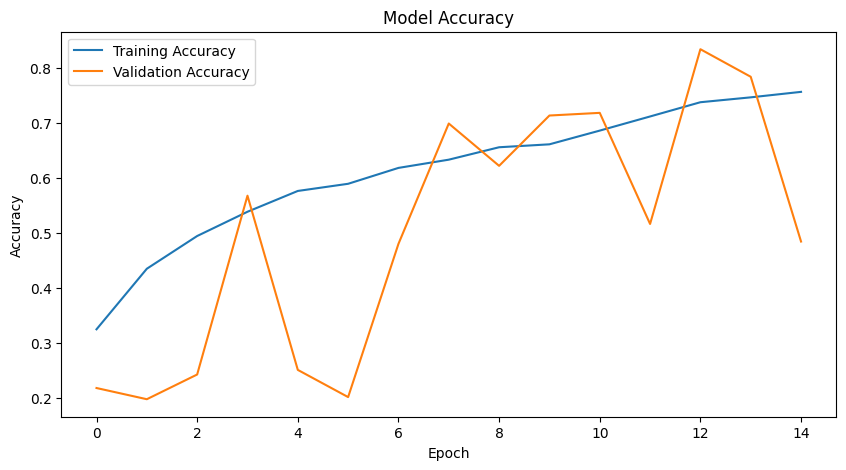

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

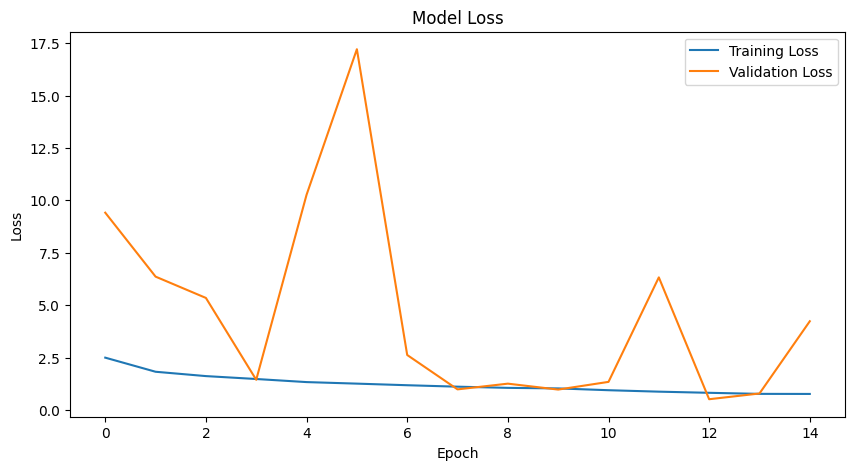

In [16]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

97/97 ━━━━━━━━━━━━━━━━━━━━ 33s 339ms/step - accuracy: 0.8217 - loss: 0.5353
Test Accuracy: 0.8217054009437561
Test Loss: 0.5353088974952698


In [18]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=encoder.classes_
))

97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 360ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.77      0.84      0.80       137
                     Pepper__bell___healthy       0.89      0.98      0.93       233
                      Potato___Early_blight       0.77      1.00      0.87       151
                       Potato___Late_blight       0.53      0.95      0.68       147
                           Potato___healthy       1.00      0.52      0.68        27
                      Tomato_Bacterial_spot       0.91      0.93      0.92       308
                        Tomato_Early_blight       0.85      0.40      0.54       153
                         Tomato_Late_blight       0.80      0.74      0.77       313
                           Tomato_Leaf_Mold       0.95      0.71      0.81       135
                  Tomato_Septoria_leaf_spot       0.70      0.75      0.72       251
Tomato_Spider_mites_Tw

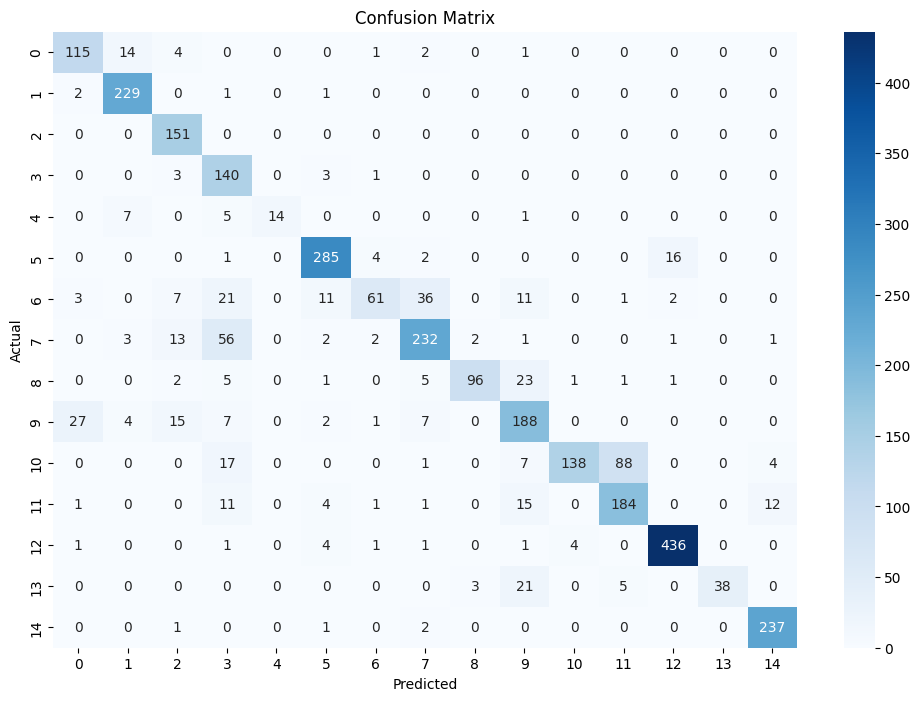

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
model.save("crop_disease_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
import numpy as np

np.save("class_names.npy", encoder.classes_)

print("Class Names Saved Successfully!")

Class Names Saved Successfully!


# Week 3
Transfer Learning with MobileNetV2

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [23]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

In [4]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

In [5]:
transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(15, activation='softmax')

])

transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [27]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 302s 655ms/step - accuracy: 0.6483 - loss: 1.0989 - val_accuracy: 0.8059 - val_loss: 0.6109
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 291s 645ms/step - accuracy: 0.7552 - loss: 0.7262 - val_accuracy: 0.8346 - val_loss: 0.5094
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 290s 641ms/step - accuracy: 0.7813 - loss: 0.6401 - val_accuracy: 0.8178 - val_loss: 0.5266
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 292s 645ms/step - accuracy: 0.7972 - loss: 0.6153 - val_accuracy: 0.8372 - val_loss: 0.4698
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 291s 643ms/step - accuracy: 0.8051 - loss: 0.5869 - val_accuracy: 0.8398 - val_loss: 0.4696
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 289s 639ms/step - accuracy: 0.8154 - loss: 0.5540 - val_accuracy: 0.8514 - val_loss: 0.4376
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 289s 639ms/step - accuracy: 0.8175 - loss: 0.5410 - val_accuracy: 0.8450 - val_loss: 0.4639
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 289s 640ms/step - accuracy: 0.8173 -

In [19]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(
    X_test,
    y_test
)

print("MobileNetV2 Accuracy:", transfer_accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 431ms/step - accuracy: 0.0811 - loss: 2.9310
MobileNetV2 Accuracy: 0.0810723528265953


In [20]:
import numpy as np

predictions = transfer_model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print("Predictions Generated!")

97/97 ━━━━━━━━━━━━━━━━━━━━ 43s 426ms/step
Predictions Generated!


In [69]:
confidence_scores = np.max(predictions, axis=1) * 100

print("First 5 confidence scores:")
print(confidence_scores[:5])
print(f"Average confidence score: {np.mean(confidence_scores):.2f}%")

First 5 confidence scores:
[29.7795   23.621372 21.856087 21.0119   18.607845]
Average confidence score: 21.58%


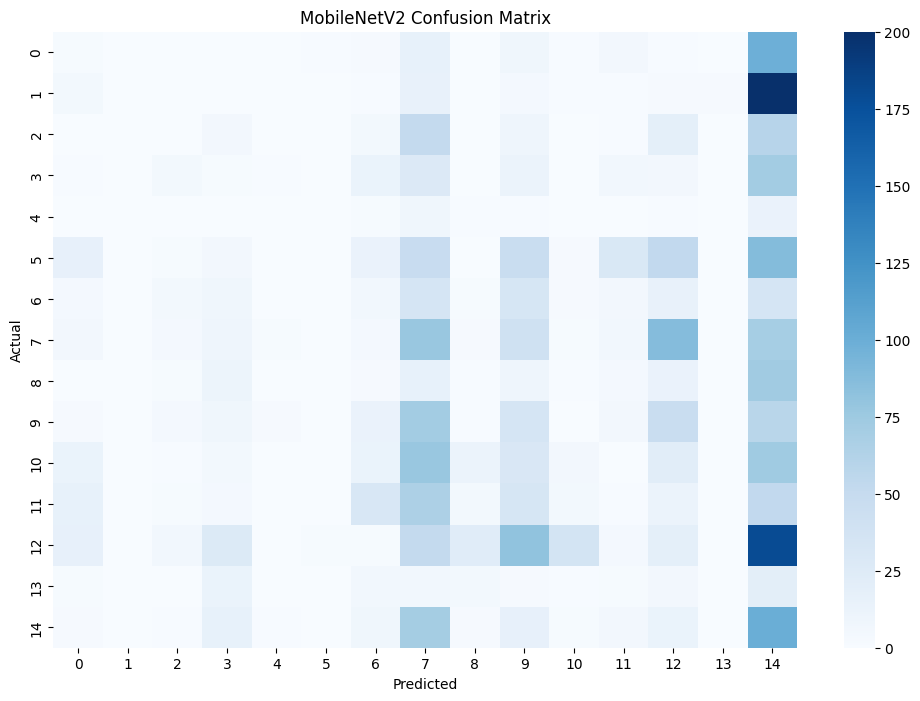

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
transfer_model.save("crop_disease_mobilenetv2.h5")

print("Week 3 Model Saved Successfully!")

Week 3 Model Saved Successfully!


In [23]:
transfer_model.save("crop_disease_mobilenetv2.h5")

print("MobileNetV2 Model Saved!")

MobileNetV2 Model Saved!


# WEEK 4
Streamlit Deployment

In [55]:
!pip install streamlit pyngrok tensorflow pillow -q

In [56]:
%%writefile app.py

import streamlit as st
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

model = load_model("crop_disease_mobilenetv2.h5")

class_names = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

st.set_page_config(page_title="Smart Crop Disease Detection")

st.title("🌱 Smart Crop Disease Detection")

uploaded_file = st.file_uploader(
    "Upload a leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(image, caption="Uploaded Leaf")

    img = image.resize((128,128))
    img = np.array(img)/255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    disease = class_names[np.argmax(prediction)]

    confidence = np.max(prediction)*100

    st.success(f"Disease: {disease}")
    st.info(f"Confidence: {confidence:.2f}%")
    st.progress(float(confidence/100))

    if "healthy" in disease.lower():
        st.success("Plant appears healthy.")
    else:
        st.warning("Disease detected. Consider treatment and monitoring.")

Overwriting app.py


In [57]:
!pkill -f streamlit
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [59]:
from pyngrok import ngrok

ngrok.set_auth_token("3Et58MbaSqhntl0BcAdhbkPJPey_6mZKLt49VShCRfBtzQnXF")
url = ngrok.connect(8501)
print(url)

NgrokTunnel: "https://punch-golf-delicate.ngrok-free.dev" -> "http://localhost:8501"
